In [159]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, f1_score

MISLABELS_CSV = Path("/home/student/lisa_ma/results/glare/19-08-26_21:11_ep-8_single-gpu/results/mislabels_list_20260819_211102.csv")
RC_XLSX       = Path("/home/student/lisa_ma/evaluation/gt_mislabels_complete.xlsx")
MAX_SCORE     = 8

FIGURES_DIR = Path("/home/student/lisa_ma/figures/ep8_no_LO")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

scores_df = pd.read_csv(MISLABELS_CSV, dtype=str, keep_default_na=False)
scores_df["glare_score"] = pd.to_numeric(scores_df["glare score"], errors="coerce")
scores_df = scores_df.dropna(subset=["glare_score"]).reset_index(drop=True)

In [160]:
# To get the mislabeled / clean label
df_rc     = pd.read_excel(RC_XLSX)                           # kein sheet_name nötig
positives = set(df_rc["sample_id"].astype(str))             # sample_id statt id, kein in_training_data Filter
scores_df["mislabeled"] = scores_df["id"].apply(lambda x: 1 if x in positives else 0)

In [161]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score

# ── Dataset summary ───────────────────────────────────────────────────────────
n_total     = len(scores_df)
n_mislabels = scores_df["mislabeled"].sum()
base_rate   = scores_df["mislabeled"].mean()

# ── Per-threshold metrics ─────────────────────────────────────────────────────
y_true   = scores_df["mislabeled"].values
inverted = MAX_SCORE - scores_df["glare_score"].values  # high = suspicious

auroc = roc_auc_score(y_true, inverted)
ap    = average_precision_score(y_true, inverted)

rows = []
for threshold in range(MAX_SCORE + 1):
    y_pred    = (scores_df["glare_score"] <= threshold).astype(int).values
    fraction  = y_pred.sum() / n_total
    recall    = recall_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    rows.append({"threshold": threshold, "fraction": fraction,
                 "recall": recall, "precision": precision, "f1": f1})

detail_df = pd.DataFrame(rows)
best      = detail_df.loc[detail_df["f1"].idxmax()]

# ── Print ─────────────────────────────────────────────────────────────────────
print("=" * 52)
print("  GLARE Run Summary — VerSe Aug 22, 2026")
print("=" * 52)
print(f"  Training samples:              {n_total:,}")
print(f"  Confirmed mislabels:           {n_mislabels}")
print(f"  Base mislabel rate:            {base_rate:.2%}")
print(f"  Training epochs:               {MAX_SCORE}")
print(f"  GLARE score range:             0 – {MAX_SCORE}")
print()
print("  Detection Performance")
print("  " + "-" * 38)
print(f"  AUROC:                         {auroc:.4f}")
print(f"  Average Precision:             {ap:.4f}")
print(f"  Best F1:                       {best.f1:.4f}  (score ≤ {int(best.threshold)})")
print(f"    Recall at best F1:           {best.recall:.2%}")
print(f"    Precision at best F1:        {best.precision:.2%}")
print(f"    Fraction checked:            {best.fraction:.2%}")
print("=" * 52)
print()
print("  Full threshold table:")
print(detail_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


  GLARE Run Summary — VerSe Aug 22, 2026
  Training samples:              19,266
  Confirmed mislabels:           109
  Base mislabel rate:            0.57%
  Training epochs:               8
  GLARE score range:             0 – 8

  Detection Performance
  --------------------------------------
  AUROC:                         0.9149
  Average Precision:             0.3248
  Best F1:                       0.3956  (score ≤ 4)
    Recall at best F1:           33.03%
    Precision at best F1:        49.32%
    Fraction checked:            0.38%

  Full threshold table:
 threshold  fraction  recall  precision     f1
         0    0.0012  0.1651     0.7826 0.2727
         1    0.0017  0.2385     0.8125 0.3688
         2    0.0021  0.2661     0.7250 0.3893
         3    0.0031  0.3028     0.5500 0.3905
         4    0.0038  0.3303     0.4932 0.3956
         5    0.0071  0.3945     0.3139 0.3496
         6    0.0210  0.6606     0.1782 0.2807
         7    0.0709  0.8624     0.0689 0.1275
   

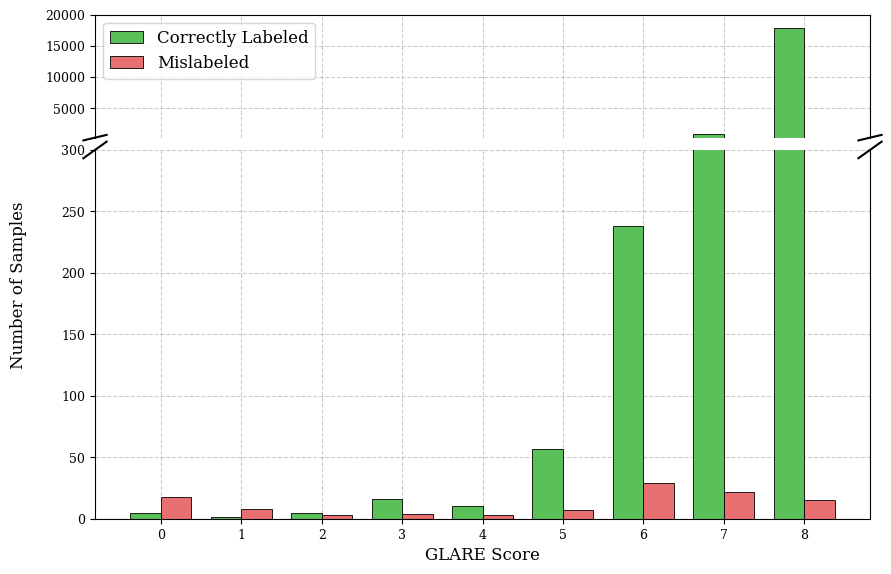

In [162]:
import matplotlib.gridspec as gridspec

score_vals      = list(range(MAX_SCORE + 1))
clean_counts    = [int(((scores_df["glare_score"] == s) & (scores_df["mislabeled"] == 0)).sum()) for s in score_vals]
mislabel_counts = [int(((scores_df["glare_score"] == s) & (scores_df["mislabeled"] == 1)).sum()) for s in score_vals]

lower_ylim = 300
top_ylim   = min(20000, int(np.ceil(max(clean_counts) * 1.15)))

fig = plt.figure(figsize=(10, 6))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)
ax_top    = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1], sharex=ax_top)

x     = np.arange(len(score_vals))
bar_w = 0.38

for ax in (ax_top, ax_bottom):
    ax.bar(x - bar_w/2, clean_counts,    width=bar_w, color="#5BBF5A", edgecolor="black", linewidth=0.6, label="Correctly Labeled")
    ax.bar(x + bar_w/2, mislabel_counts, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label="Mislabeled")
    ax.set_facecolor("white")
    ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
    ax.set_axisbelow(True)

ax_top.set_ylim(lower_ylim, top_ylim)
ax_bottom.set_ylim(0, lower_ylim)
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False, labelbottom=False)
ax_top.xaxis.set_major_formatter(plt.NullFormatter())
ax_bottom.xaxis.tick_bottom()

d = 0.015
for ax, y_vals in [(ax_top, (-d*1.5, +d*1.5)), (ax_bottom, (1-d*1.5, 1+d*1.5))]:
    kw = dict(transform=ax.transAxes, color="k", clip_on=False)
    ax.plot((-d, +d),   y_vals, **kw)
    ax.plot((1-d, 1+d), y_vals, **kw)

ax_bottom.set_xlabel("GLARE Score", fontsize=12)
ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels(score_vals, fontsize=10)
ax_top.tick_params(axis="both", labelsize=9)
ax_bottom.tick_params(axis="both", labelsize=9)
ax_top.legend(fontsize=12, frameon=True, loc="upper left")
fig.supylabel("Number of Samples", fontsize=12, x=0.04)
fig.subplots_adjust(top=0.95)
plt.savefig(FIGURES_DIR / "histogram_all_ep8_no_LO.pdf", dpi=300, bbox_inches="tight")
plt.show()


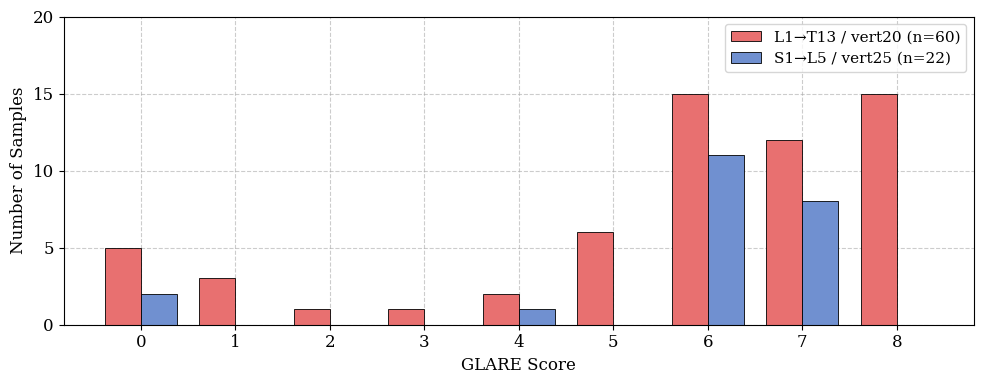

In [164]:
# ── Histogram: T13-extra — L1→T13 (vert20) vs S1→L5 (vert25) ────────────────
v20_ids = set(df_rc[(df_rc["anomaly_type"] == "T13_extra") & (df_rc["vert_id"] == 20)]["sample_id"].astype(str))
v25_ids = set(df_rc[(df_rc["anomaly_type"] == "T13_extra") & (df_rc["vert_id"] == 25)]["sample_id"].astype(str))

v20_df = scores_df[scores_df["id"].isin(v20_ids)]
v25_df = scores_df[scores_df["id"].isin(v25_ids)]

score_vals = list(range(MAX_SCORE + 1))
v20_counts = [int((v20_df["glare_score"] == s).sum()) for s in score_vals]
v25_counts = [int((v25_df["glare_score"] == s).sum()) for s in score_vals]

x     = np.arange(len(score_vals))
bar_w = 0.38

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - bar_w/2, v20_counts, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label=f"L1→T13 / vert20 (n={len(v20_df)})")
ax.bar(x + bar_w/2, v25_counts, width=bar_w, color="#7090D0", edgecolor="black", linewidth=0.6, label=f"S1→L5 / vert25 (n={len(v25_df)})")
ax.set_xlabel("GLARE Score", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(score_vals)
ax.set_ylim(0, 20)
ax.set_yticks(range(0, 21, 5))
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "histogram_T13extra_ep8_no_LO.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [165]:
# ── ep-8 run: load data ───────────────────────────────────────────────────────
MISLABELS_CSV_8 = Path("/home/student/lisa_ma/results/glare/19-08-26_21:11_ep-8_single-gpu/results/mislabels_list_20260819_211102.csv")
MAX_SCORE_8 = 8

scores_df_8 = pd.read_csv(MISLABELS_CSV_8, dtype=str, keep_default_na=False)
scores_df_8["glare_score"] = pd.to_numeric(scores_df_8["glare score"], errors="coerce")
scores_df_8 = scores_df_8.dropna(subset=["glare_score"]).reset_index(drop=True)
scores_df_8["mislabeled"] = scores_df_8["id"].apply(lambda x: 1 if x in positives else 0)

score_vals_8      = list(range(MAX_SCORE_8 + 1))
clean_counts_8    = [int(((scores_df_8["glare_score"] == s) & (scores_df_8["mislabeled"] == 0)).sum()) for s in score_vals_8]
mislabel_counts_8 = [int(((scores_df_8["glare_score"] == s) & (scores_df_8["mislabeled"] == 1)).sum()) for s in score_vals_8]

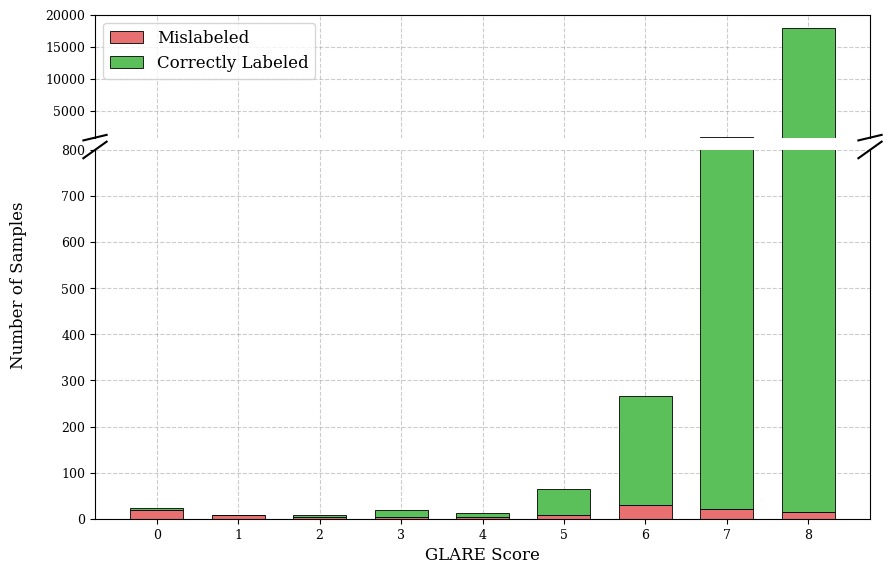

In [166]:
# ── Combined histogram (ep-8, lower_ylim=800) — stacked ──────────────────────
lower_ylim_8 = 800
top_ylim_8   = min(20000, int(np.ceil(max(c + m for c, m in zip(clean_counts_8, mislabel_counts_8)) * 1.15)))

fig = plt.figure(figsize=(10, 6))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)
ax_top    = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1], sharex=ax_top)

x     = np.arange(len(score_vals_8))
bar_w = 0.65

for ax in (ax_top, ax_bottom):
    ax.bar(x, mislabel_counts_8, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label="Mislabeled")
    ax.bar(x, clean_counts_8,    width=bar_w, color="#5BBF5A", edgecolor="black", linewidth=0.6, label="Correctly Labeled", bottom=mislabel_counts_8)
    ax.set_facecolor("white")
    ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
    ax.set_axisbelow(True)

ax_top.set_ylim(lower_ylim_8, top_ylim_8)
ax_bottom.set_ylim(0, lower_ylim_8)
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False, labelbottom=False)
ax_top.xaxis.set_major_formatter(plt.NullFormatter())
ax_bottom.xaxis.tick_bottom()

d = 0.015
for ax, y_vals in [(ax_top, (-d*1.5, +d*1.5)), (ax_bottom, (1-d*1.5, 1+d*1.5))]:
    kw = dict(transform=ax.transAxes, color="k", clip_on=False)
    ax.plot((-d, +d),   y_vals, **kw)
    ax.plot((1-d, 1+d), y_vals, **kw)

ax_bottom.set_xlabel("GLARE Score", fontsize=12)
ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels(score_vals_8, fontsize=10)
ax_top.tick_params(axis="both", labelsize=9)
ax_bottom.tick_params(axis="both", labelsize=9)
ax_top.legend(fontsize=12, frameon=True, loc="upper left")
fig.supylabel("Number of Samples", fontsize=12, x=0.04)
fig.subplots_adjust(top=0.95)
plt.savefig(FIGURES_DIR / "histogram_all_ep8_no_LO.pdf", dpi=300, bbox_inches="tight")
plt.show()

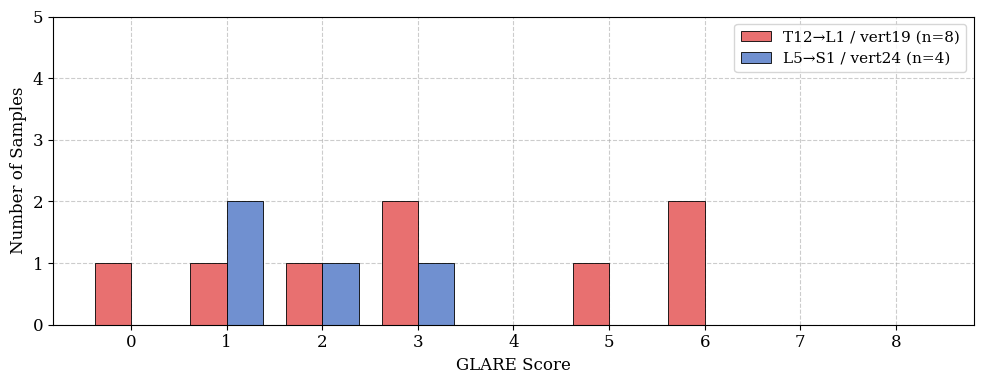

In [167]:
# ── Histogram: T12-missing ep-8 — T12→L1 (vert19) vs L5→S1 (vert24) ─────────
v19_ids = set(df_rc[(df_rc["anomaly_type"] == "T12_missing") & (df_rc["vert_id"] == 19)]["sample_id"].astype(str))
v24_ids = set(df_rc[(df_rc["anomaly_type"] == "T12_missing") & (df_rc["vert_id"] == 24)]["sample_id"].astype(str))

v19_df_8 = scores_df_8[scores_df_8["id"].isin(v19_ids)]
v24_df_8 = scores_df_8[scores_df_8["id"].isin(v24_ids)]

score_vals_8 = list(range(MAX_SCORE_8 + 1))
v19_counts_8 = [int((v19_df_8["glare_score"] == s).sum()) for s in score_vals_8]
v24_counts_8 = [int((v24_df_8["glare_score"] == s).sum()) for s in score_vals_8]

x     = np.arange(len(score_vals_8))
bar_w = 0.38

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - bar_w/2, v19_counts_8, width=bar_w, color="#E87070", edgecolor="black", linewidth=0.6, label=f"T12→L1 / vert19 (n={len(v19_df_8)})")
ax.bar(x + bar_w/2, v24_counts_8, width=bar_w, color="#7090D0", edgecolor="black", linewidth=0.6, label=f"L5→S1 / vert24 (n={len(v24_df_8)})")
ax.set_xlabel("GLARE Score", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(score_vals_8)
ax.set_ylim(0, 5)
ax.set_yticks(range(0, 6, 1))
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "histogram_T12missing_ep8_no_LO.pdf", dpi=300, bbox_inches="tight")
plt.show()

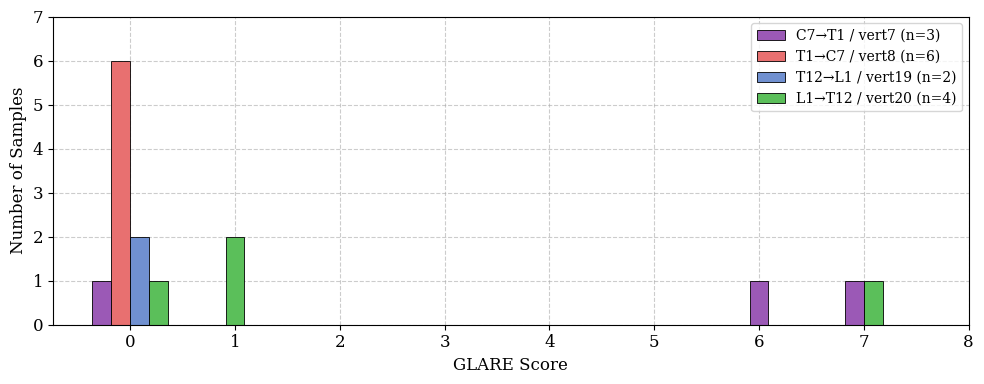

In [168]:
# ── Histogram: LabelShift ep-8 — C/T and T/L boundary mislabels ──────────────
import matplotlib.patches as mpatches

groups = [
    ("label_shift_C_as_T", 7,  "C7→T1 / vert7",  "#9B59B6"),
    ("label_shift_T_as_C", 8,  "T1→C7 / vert8",  "#E87070"),
    ("label_shift_TL",     19, "T12→L1 / vert19", "#7090D0"),
    ("label_shift_TL",     20, "L1→T12 / vert20", "#5BBF5A"),
]

score_vals_8 = list(range(MAX_SCORE_8 + 1))
x     = np.arange(len(score_vals_8))
bar_w = 0.18

# Pre-compute counts per group
group_counts = []
group_meta   = []
for atype, vert, label_str, color in groups:
    ids = set(df_rc[(df_rc["anomaly_type"] == atype) & (df_rc["vert_id"] == vert)]["sample_id"].astype(str))
    sub = scores_df_8[scores_df_8["id"].isin(ids)]
    group_counts.append([int((sub["glare_score"] == s).sum()) for s in score_vals_8])
    group_meta.append((label_str, color, len(sub)))

fig, ax = plt.subplots(figsize=(10, 4))

for gi, (counts, (label_str, color, n_sub)) in enumerate(zip(group_counts, group_meta)):
    for si, (xi, cnt) in enumerate(zip(x, counts)):
        if cnt == 0:
            continue
        active   = [g for g in range(len(groups)) if group_counts[g][si] > 0]
        n_active = len(active)
        rank     = active.index(gi)
        offset   = (rank - (n_active - 1) / 2) * bar_w
        ax.bar(xi + offset, cnt, width=bar_w, color=color,
               edgecolor="black", linewidth=0.6)

legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor="black", linewidth=0.6,
                   label=f"{label_str} (n={n})")
    for label_str, color, n in group_meta
]

ax.set_xlabel("GLARE Score", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(score_vals_8)
ax.set_ylim(0, 7)
ax.set_yticks(range(0, 8, 1))
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend(handles=legend_handles, fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "histogram_LabelShift_ep8_no_LO.pdf", dpi=300, bbox_inches="tight")
plt.show()

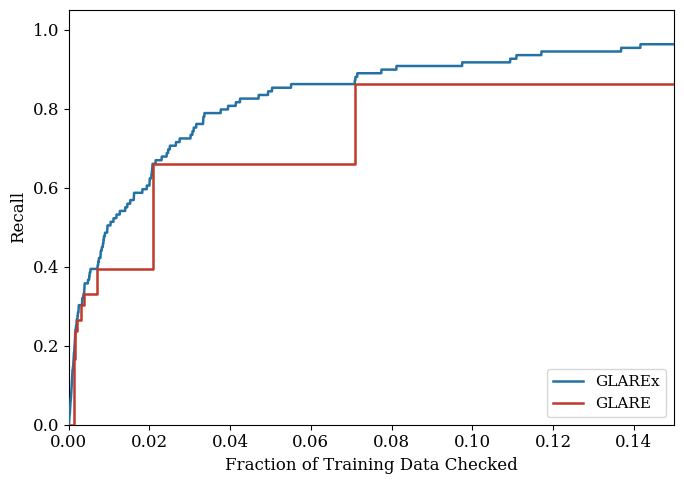

In [169]:
# Recall curve
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fracs_gx, rec_gx, color=COLOR_GLAREX, linewidth=1.8, label="GLAREx", zorder=3)
ax.step(glare_df["frac"], glare_df["recall"], where="post", color=COLOR_GLARE, linewidth=1.8, label="GLARE", zorder=4)
ax.set_xlabel("Fraction of Training Data Checked", fontsize=12)
ax.set_ylabel("Recall", fontsize=12)
ax.set_xlim(0, 0.15)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11, frameon=True, loc="lower right")
ax.set_facecolor("white")
ax.grid(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "recall_curve_ep8_no_LO.pdf", bbox_inches="tight")
plt.show()

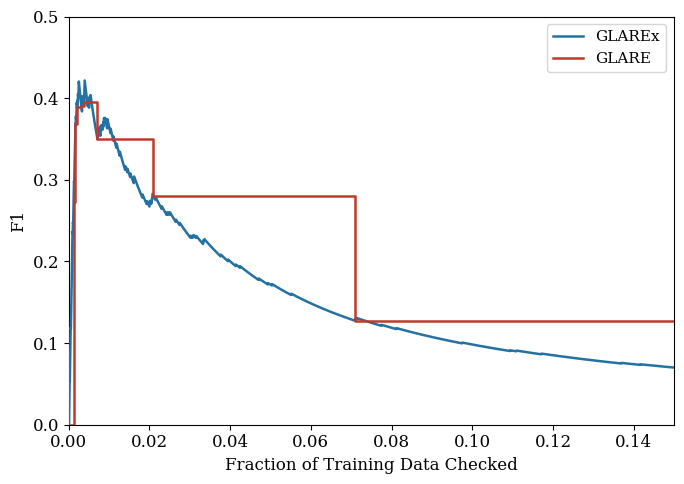

In [170]:
# F1 curve
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fracs_gx, f1_gx, color=COLOR_GLAREX, linewidth=1.8, label="GLAREx", zorder=3)
ax.step(glare_df["frac"], glare_df["f1"], where="post", color=COLOR_GLARE, linewidth=1.8, label="GLARE", zorder=4)
ax.set_xlabel("Fraction of Training Data Checked", fontsize=12)
ax.set_ylabel("F1", fontsize=12)
ax.set_xlim(0, 0.15)
ax.set_ylim(0, 0.5)
ax.legend(fontsize=11, frameon=True, loc="upper right")
ax.set_facecolor("white")
ax.grid(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "f1_curve_ep8_no_LO.pdf", bbox_inches="tight")
plt.show()

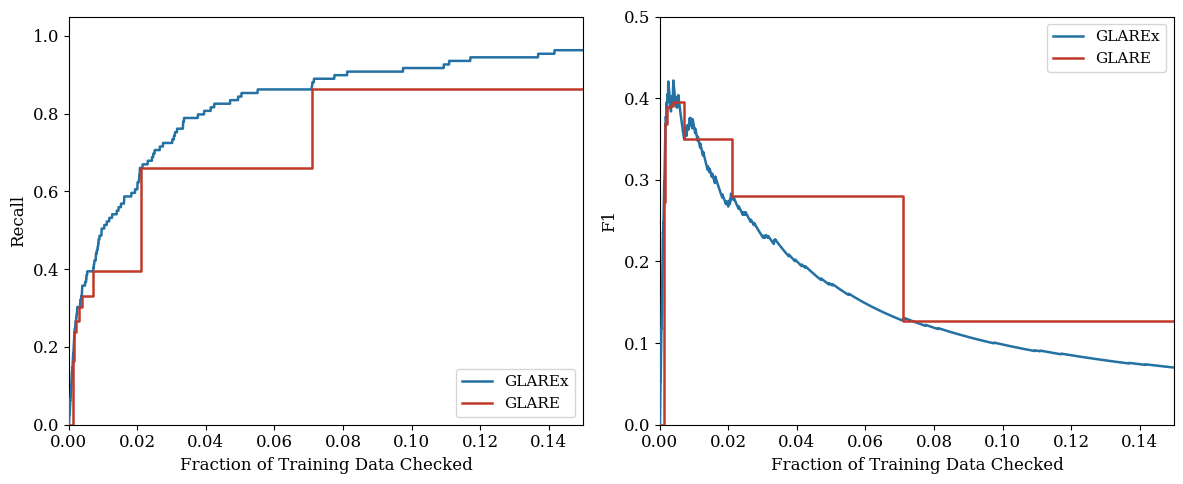

In [171]:
# Recall + F1 side by side
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 5))

# Recall
ax_l.plot(fracs_gx, rec_gx, color=COLOR_GLAREX, linewidth=1.8, label="GLAREx", zorder=3)
ax_l.step(glare_df["frac"], glare_df["recall"], where="post", color=COLOR_GLARE, linewidth=1.8, label="GLARE", zorder=4)
ax_l.set_xlabel("Fraction of Training Data Checked", fontsize=12)
ax_l.set_ylabel("Recall", fontsize=12)
ax_l.set_xlim(0, 0.15)
ax_l.set_ylim(0, 1.05)
ax_l.legend(fontsize=11, frameon=True, loc="lower right")
ax_l.set_facecolor("white")
ax_l.grid(False)

# F1
ax_r.plot(fracs_gx, f1_gx, color=COLOR_GLAREX, linewidth=1.8, label="GLAREx", zorder=3)
ax_r.step(glare_df["frac"], glare_df["f1"], where="post", color=COLOR_GLARE, linewidth=1.8, label="GLARE", zorder=4)
ax_r.set_xlabel("Fraction of Training Data Checked", fontsize=12)
ax_r.set_ylabel("F1", fontsize=12)
ax_r.set_xlim(0, 0.15)
ax_r.set_ylim(0, 0.5)
ax_r.legend(fontsize=11, frameon=True, loc="upper right")
ax_r.set_facecolor("white")
ax_r.grid(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "recall_f1_curve_ep8_no_LO.pdf", bbox_inches="tight")
plt.show()

In [174]:
# ── GLAREx stats ──────────────────────────────────────────────────────────────
gx_df = scores_df_8.copy()
if "glarex_score" not in gx_df.columns or gx_df["glarex_score"].isna().all():
    gx_df["glarex_score"] = pd.to_numeric(gx_df.get("glarex score", pd.Series(dtype=float)), errors="coerce")
if gx_df["glarex_score"].isna().all():
    MISLABELS_XLSX_8 = Path("/home/student/lisa_ma/results/glare/19-08-26_21:11_ep-8_single-gpu/results/mislabels_list_20260819_211102.xlsx")
    xlsx_8 = pd.read_excel(MISLABELS_XLSX_8, dtype=str)
    xlsx_8["glarex_score"] = pd.to_numeric(xlsx_8.get("glarex score", pd.Series(dtype=float)), errors="coerce")
    gx_df = gx_df.merge(xlsx_8[["id", "glarex_score"]], on="id", how="left")

gx = gx_df.dropna(subset=["glarex_score"]).sort_values("glarex_score").reset_index(drop=True)
n_gx  = len(gx)
n_pos = int(gx["mislabeled"].sum())
cum   = gx["mislabeled"].cumsum().values
k     = np.arange(1, n_gx + 1)
prec  = cum / k
rec   = cum / n_pos
denom = prec + rec
f1    = np.where(denom > 0, 2 * prec * rec / denom, 0.0)
fracs = k / n_gx

idx_100_recall = np.searchsorted(rec, 1.0, side="left")
idx_best_f1    = np.argmax(f1)
idx_best_prec  = np.argmax(prec)

print(f"GLAREx — total samples: {n_gx}, GT mislabels: {n_pos}")
print(f"  100% recall at rank {idx_100_recall+1}, fraction {fracs[idx_100_recall]*100:.2f}%")
print(f"  Highest precision:  {prec[idx_best_prec]*100:.1f}% at fraction {fracs[idx_best_prec]*100:.3f}%")
print(f"  Best F1: {f1[idx_best_f1]:.4f} at fraction {fracs[idx_best_f1]*100:.3f}%  (recall={rec[idx_best_f1]*100:.1f}%, prec={prec[idx_best_f1]*100:.1f}%)")

GLAREx — total samples: 19266, GT mislabels: 109
  100% recall at rank 3639, fraction 18.89%
  Highest precision:  83.3% at fraction 0.093%
  Best F1: 0.4216 at fraction 0.394%  (recall=35.8%, prec=51.3%)


/tmp/ipykernel_3825864/3577592491.py:19: RuntimeWarning: invalid value encountered in divide
  f1    = np.where(denom > 0, 2 * prec * rec / denom, 0.0)
